#4장
목표는 LLM 구현이다. 학습은 다음 장에서 할 예정

LLM은 한 번에 하나의 token씩 새로운 text를 생성하도록 고안된 대규모 심층 신경망 구조이다. 모델이 클 뿐 구조는 비교적 간단하다.

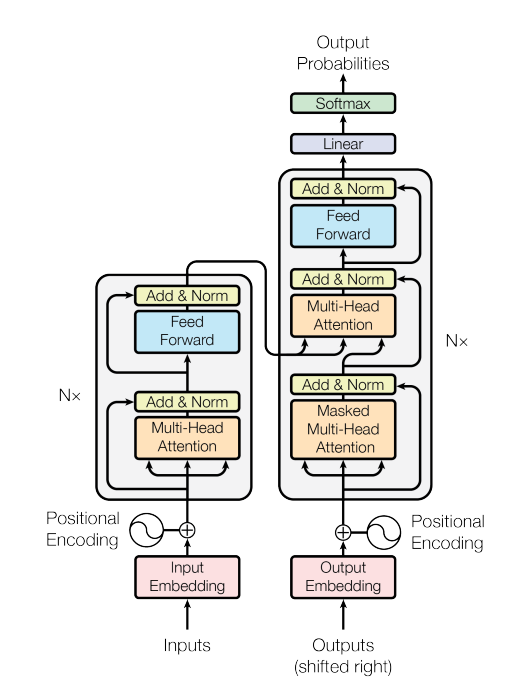

위 그림은 transformer 구조인데, LLM은 1개 이상의 transformer block으로 구성되어 있다. 이때 LLM의 종류에 따라 transformer에서 encoder만 사용하는 경우가 있고, decoder만 사용하는 경우가 있고, 둘 다 사용하는 경우가 있다.

결국 LLM은 input sequence가 들어오면 2장에서 배운 tokenization과 embedding과정을 거쳐 전처리되고, 이렇게 전처리된 vector값이 3장에서 배운 masked multi-head attention module에 입력되어 특정한 출력값을 도출해 내는 구조이다.

In [1]:
#구현할 소규모 GPT-2 model의 설정을 저장
GPT_CONFIG_124M={
    "vocab_size":50257,
    "context_length":1024,
    "emb_dim":768,
    "n_heads":12,
    "n_layers":12,
    "drop_rate":0.1,
    "qkv_bias":False
}

In [2]:
#전체 모델의 구조를 확인하기 위해 GPT 더미 모델을 만들겠다.
#이 class에는 token embedding, position embedding, dropout, transformer block, 최종 normalization, linear output layer로 구성된다.

import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])
    self.trf_blocks=nn.Sequential(
        *[DummyTransformerBlcok(cfg)
        for _ in range(cfg["n_layers"])]
    )
    self.final_norm=DummyLayerNorm(cfg["emb_dim"])
    self.out_head=nn.Linear(
        cfg["emb_dim"],cfg["vocab_size"],bias=False
    )

  #다음 함수는 input index를 위한 token embedding과 position embedding을 계산하고, dropout을 적용
  #transformer block으로 data를 처리하고, normalization 적용, 최종적으로 logit을 생성한다.
  def forward(self,in_idx):
    batch_size,seq_len=in_idx.shape
    tok_embeds=self.tok_emb(in_idx)
    pos_embeds=self.pos_emb(
        torch.arange(seq_len,device=in_idx.device)
    )
    x=tok_embeds+pos_embeds
    x=self.drop_emb(x)
    x=self.trf_blocks(x)
    x=self.final_norm(x)
    logits=self.out_head(x)
    return logits

class DummyTransformerBlcok(nn.Module):
  def __init__(self,cfg):
    super().__init__()
  def forward(self,x):
    return x

class DummyLayerNorm(nn.Module):
  def __init__(self,normalized_shape,eps=1e-5):
    super().__init__()

  def forward(self,x):
    return x

In [3]:
#tiktoken라는 tokenizer로 2개의 text로 구성된 batch를 tokenization하겠다.

import tiktoken

tokenizer=tiktoken.get_encoding("gpt2")
batch=[]
txt1="Every effort moves you"
txt2="Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
print(f"txt1에 대한 tensor: {torch.tensor(tokenizer.encode(txt1))}")
batch.append(torch.tensor(tokenizer.encode(txt2)))
print(f"txt2에 대한 tensor: {torch.tensor(tokenizer.encode(txt2))}")
print(torch.stack(batch,dim=-1))  #두 tensor을 각각 column vector형태로 저장한다.
batch=torch.stack(batch,dim=0)    #두 tensor을 각각 row vector 형태로 저장한다.
print(batch)

#결과로는 두 text의 token ID가 출력된다.
#각 행은 txt1과 txt2에 대응된다.

txt1에 대한 tensor: tensor([6109, 3626, 6100,  345])
txt2에 대한 tensor: tensor([6109, 1110, 6622,  257])
tensor([[6109, 6109],
        [3626, 1110],
        [6100, 6622],
        [ 345,  257]])
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [4]:
#DummyGPTModel 모델을 초기화하고 tokenization된 batch를 모델에 입력한다.
torch.manual_seed(123)
model=DummyGPTModel(GPT_CONFIG_124M)
logits=model(batch)
print("출력 크기:",logits.shape)
print(logits)
print(f"logits의 row vector의 차원: {logits[0][0].shape}")

#tensor의 행은 2이며(input text가 2문장), 각 행은 4개의 token으로 구성된다(각 문장을 구성하는 단어가 4개이다). 그리고 logit tensor의 각 row vector는 50257 차원의 vector로 표현된다.
#이 50257는 vocabulary의 크기이며, 차후에 softmax함수로 logits의 각 row vector를 vocabulary내에 있는 각 token의 확률로 표현한다.
#LLM은 이 확률이 가장 큰 token을 다음 단어로 출력한다.

출력 크기: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)
logits의 row vector의 차원: torch.Size([50257])


Layer Normalization

신경망 층의 출력을 평균이 0이고, 분산이 1이 되도록 조정한다. 이를 통해 가중치의 수렴 속도를 높이며 일관되고, 안정적인 훈련을 보장한다.

In [5]:
#vanishing gradient problem을 회피하기 위해 layer normalization을 적용한다.
#일단 5개의 입력과 6개의 출력을 가진 신경망 layer에 2개의 입력 샘플을 적용한다.
torch.manual_seed(123)
batch_example=torch.randn(2,5)
print(f"input:\n{batch_example}\n\n")
layer=nn.Sequential(nn.Linear(5,6),nn.ReLU())
out=layer(batch_example)
print(f"output:\n{out}")

input:
tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])


output:
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [6]:
#위에서 도출한 출력에 layer normalization을 적용하기 전에 각 행의 평균과 분산을 확인한다.

mean=out.mean(dim=-1,keepdim=True)
var=out.var(dim=-1,keepdim=True)
print("평균:\n",mean)
print("분산:=\n",var)

평균:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
분산:=
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [7]:
#lyaer normalization을 적용
out_norm=(out-mean)/torch.sqrt(var)
print("표준편차: \n",torch.sqrt(var))
print(out_norm.sum(dim=-1))
n_mean=out_norm.mean(dim=-1,keepdim=True)
n_var=out_norm.var(dim=-1,keepdim=True)
print("정규화된 층 출력:\n",out_norm)
print("평균:\n",n_mean)
print("분산:\n",n_var)

#이때 각 행의 합은 1이 아니다. 물론 각 열의 합도 1이 아니다.
#각 행의 평균도 1이 아니다.
#하지만 각 행의 분산은 1이다.

표준편차: 
 tensor([[0.1519],
        [0.1996]], grad_fn=<SqrtBackward0>)
tensor([5.9605e-08, 1.1921e-07], grad_fn=<SumBackward1>)
정규화된 층 출력:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
평균:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
분산:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [8]:
#이러한 layer normalization을 pytorch module로 encapsulation 해보겠다.

class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps=1e-5 #normalization할 때 0 나눗셈을 방지하기 위해 분산에 더해지는 작은 상수값
    #LLM이 훈련하는 동안 다음 두 파라미터를 조정하는 것이 훈련 작업에서 모델의 성능을 향상시킨다고 판단되면 자동으로 조정한다.
    self.scale=nn.Parameter(torch.ones(emb_dim))
    print(f"self.scale에 대한 값:\n{self.scale}\n")
    self.shift=nn.Parameter(torch.zeros(emb_dim))
    print(f"self.shift에 대한 값:\n{self.shift}\n")

  def forward(self, x):
    mean=x.mean(dim=-1,keepdim=True)
    var=x.var(dim=-1,keepdim=True,unbiased=False)
    norm_x=(x-mean)/torch.sqrt(var+self.eps)
    return self.scale*norm_x+self.shift #scaling과 shift는 왜 하는가?

In [9]:
#LayerNorm module을 batch에 적용
ln=LayerNorm(emb_dim=5)
out_ln=ln(batch_example)
print(f"layer normalization을 했을 때의 input:\n{out_ln}")
mean=out_ln.mean(dim=-1,keepdim=True)

var=out_ln.var(dim=-1,unbiased=False,keepdim=True)
print("평균:\n",mean)
print("분상:\n",var)

self.scale에 대한 값:
Parameter containing:
tensor([1., 1., 1., 1., 1.], requires_grad=True)

self.shift에 대한 값:
Parameter containing:
tensor([0., 0., 0., 0., 0.], requires_grad=True)

layer normalization을 했을 때의 input:
tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
        [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]], grad_fn=<AddBackward0>)
평균:
 tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
분상:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


batch 차원을 따라 normalization하는 batch normalization과 달리 layer normalization은 특성 차원을 따라 normalization한다.

In [10]:
#activation function으로는 GELU을 사용한다.
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self,x):
    return 0.5 * x *(1+torch.tanh(
        torch.sqrt(torch.tensor(2.0/torch.pi))*
                   (x+0.044715*torch.pow(x,3))
    ))

"""
def forward(self,x):
    return 0.5 * x *(1+torch.tanh(
        torch.sqrt(torch.tensor(2.0/torch.pi)*
                   (x+0.044715*torch.pow(x,3)))
                                             _
    ))

위 함수에서 밑줄 친 부분이 오타였다. 이 때문에 정의한 GELU()함수가 음수값을 처리하지 못하게 되고(음수 입력에 대한 출력이 nan으로 나옴),
밑에 있는 ExampleDeepNeuralNetwork() class의 nn.Linear()의 음수 입력에 대한 출력이 nan으로 출력되게 되는 오류가 발생하였다.
"""

'\ndef forward(self,x):\n    return 0.5 * x *(1+torch.tanh(\n        torch.sqrt(torch.tensor(2.0/torch.pi)*\n                   (x+0.044715*torch.pow(x,3)))\n                                             _\n    ))\n\n위 함수에서 밑줄 친 부분이 오타였다. 이 때문에 정의한 GELU()함수가 음수값을 처리하지 못하게 되고(음수 입력에 대한 출력이 nan으로 나옴),\n밑에 있는 ExampleDeepNeuralNetwork() class의 nn.Linear()의 음수 입력에 대한 출력이 nan으로 출력되게 되는 오류가 발생하였다.\n'

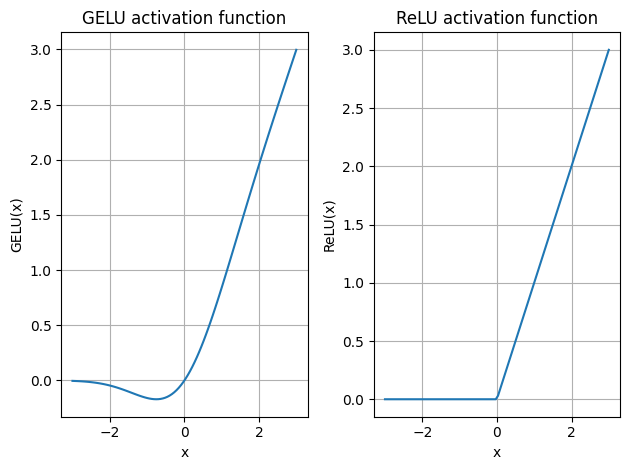

In [11]:
#GELU와 ReLU 비교

import matplotlib.pyplot as plt
gelu, relu=GELU(),nn.ReLU()

x=torch.linspace(-3,3,100)  #x값의 범위가 -3부터 3일 때 그때의 함수값을 보겠다.
y_gelu,y_relu=gelu(x),relu(x)
for i,(y,label) in enumerate(zip([y_gelu,y_relu],["GELU","ReLU"]),1):
  plt.subplot(1,2,i)
  plt.plot(x,y)
  plt.title(f"{label} activation function")
  plt.xlabel("x")
  plt.ylabel(f"{label}(x)")
  plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
#GELU를 사용해 LLM의 transformer block에 사용할 작은 신경망 module인 FeedForward를 구현해 보겠다.
#GELU가 부드럽기 때문에 훈련 과정에서 최적화가 잘되는 성질이 있다. 이를 통해 모델 파라미터를 미묘하게 조절할 수 있다.
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers=nn.Sequential(
        nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),   #입력은 768차원 출력은 3072차원
        GELU(), #입력은 3072차원 출력은 3072차원
        nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]),   #입력은 3072차원 출력은 768차원
    )

  def forward(self,x):
    return self.layers(x)

In [13]:
#token embedding 크기를 768로 하여 새로운 FeedForward module 초기화
ffn=FeedForward(GPT_CONFIG_124M)
x=torch.rand(2,3,768)
out=ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


다음으로는 서로 다른 신경망 층 사이에 추가하는 shortcut connection(residual connection라고도 부름)을 알아 보겠다.

이 기법으로 훈련 성능을 향상시킬 수 있다.

In [14]:
#forwar method에 residual connection을 추가한다.

class ExampleDeepNeuralNetwork(nn.Module):
  def __init__(self,layer_sizes,use_shortcut):
    super().__init__()
    #residual connection의 유무로 backpropagation 과정에서 gradient vanishing 문제를 해결하기 위해 사용한다.
    self.use_shortcut=use_shortcut
    #5개의 layer을 만든다.
    self.layers=nn.ModuleList([
        nn.Sequential(nn.Linear(layer_sizes[0],layer_sizes[1]),
                      GELU()),
        nn.Sequential(nn.Linear(layer_sizes[1],layer_sizes[2]),
                      GELU()),
        nn.Sequential(nn.Linear(layer_sizes[2],layer_sizes[3]),
                      GELU()),
        nn.Sequential(nn.Linear(layer_sizes[3],layer_sizes[4]),
                      GELU()),
        nn.Sequential(nn.Linear(layer_sizes[4],layer_sizes[5]),
                      GELU())
    ])

  def forward(self,x):
    for layer in self.layers:
      #현재 layer의 출력을 계산한다.
      layer_output=layer(x)
      print(layer_output,",,,x->,,,",x,layer)
      #residual connection을 적용할 수 있는지 확인한다.
      #self.use_shortcut이 True이고, layer의 출력과 입력의 크기가 같을 때 적용한다.
      if self.use_shortcut and x.shape==layer_output.shape:
        x=x+layer_output
      else:
        x=layer_output
    return x

In [15]:
#residual connection이 없는 신경망을 초기화해 보겠다.
layer_sizes=[3,3,3,3,3,1]
sample_input=torch.tensor([[1.,0.0,-1.]])
torch.manual_seed(123)
model_without_shortcut=ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)

In [16]:
#model의 backpropagation에서 gradient를 계산하는 함수 구현

def print_gradients(model,x):
  output=model(x)
  target=torch.tensor([[0.,0.,0.]])
  loss=nn.MSELoss()
  loss=loss(output,target)
  loss.backward()
  for name, param in model.named_parameters():
    if 'weight' in name:
      print(f"{name}의 평균 gradient는 {param.grad.abs().mean().item()}입니다.")

In [17]:
#위 함수를 residual connection이 없는 모델에 적용해보겠다.
#다음 코드를 보면 알 수 있듯이 초반 layer로 갈 수록 gradient는 점점 작아진다.
#즉 vanishing gradient문제가 발생한 것이다.
print_gradients(model_without_shortcut, sample_input)

tensor([[ 0.1948, -0.1414,  0.0909]], grad_fn=<MulBackward0>) ,,,x->,,, tensor([[ 1.,  0., -1.]]) Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)
tensor([[0.0219, 0.1376, 0.3824]], grad_fn=<MulBackward0>) ,,,x->,,, tensor([[ 0.1948, -0.1414,  0.0909]], grad_fn=<MulBackward0>) Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)
tensor([[0.0895, 0.2220, 0.0362]], grad_fn=<MulBackward0>) ,,,x->,,, tensor([[0.0219, 0.1376, 0.3824]], grad_fn=<MulBackward0>) Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)
tensor([[-0.0361, -0.0550,  0.1197]], grad_fn=<MulBackward0>) ,,,x->,,, tensor([[0.0895, 0.2220, 0.0362]], grad_fn=<MulBackward0>) Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)
tensor([[0.0610]], grad_fn=<MulBackward0>) ,,,x->,,, tensor([[-0.0361, -0.0550,  0.1197]], grad_fn=<MulBackward0>) Sequential(
  (0): Linear(in_features=3, out_features=1, bias

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 3])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [18]:
#위 함수를 residual conntection을 가진 model에 적용해보겠다.
torch.manual_seed(123)
model_with_shortcut=ExampleDeepNeuralNetwork(
    layer_sizes,use_shortcut=True
)
print_gradients(model_with_shortcut,sample_input)

tensor([[ 0.1948, -0.1414,  0.0909]], grad_fn=<MulBackward0>) ,,,x->,,, tensor([[ 1.,  0., -1.]]) Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)
tensor([[-0.0959, -0.1031, -0.0014]], grad_fn=<MulBackward0>) ,,,x->,,, tensor([[ 1.1948, -0.1414, -0.9091]], grad_fn=<AddBackward0>) Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)
tensor([[0.0782, 1.1798, 0.0958]], grad_fn=<MulBackward0>) ,,,x->,,, tensor([[ 1.0989, -0.2445, -0.9104]], grad_fn=<AddBackward0>) Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)
tensor([[-0.1338,  0.0577,  0.4149]], grad_fn=<MulBackward0>) ,,,x->,,, tensor([[ 1.1771,  0.9354, -0.8146]], grad_fn=<AddBackward0>) Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)
tensor([[0.7669]], grad_fn=<MulBackward0>) ,,,x->,,, tensor([[ 1.0433,  0.9930, -0.3997]], grad_fn=<AddBackward0>) Sequential(
  (0): Linear(in_features=3, out_feature

In [19]:
!wget https://github.com/udasuja/study_LLM/raw/main/previous_chapters.py
from previous_chapters import MultiHeadAttention

--2026-05-01 12:26:25--  https://github.com/udasuja/study_LLM/raw/main/previous_chapters.py
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/udasuja/study_LLM/main/previous_chapters.py [following]
--2026-05-01 12:26:25--  https://raw.githubusercontent.com/udasuja/study_LLM/main/previous_chapters.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18236 (18K) [text/plain]
Saving to: ‘previous_chapters.py’

previous_chapters.p 100%[===================>]  17.81K  --.-KB/s    in 0.001s  

2026-05-01 12:26:25 (21.2 MB/s) - ‘previous_chapters.py’ saved [18236/18236]



In [20]:
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [21]:
#위 MultiHeadAttention을 이용하여 GPT의 transformer block을 구현하겠다.
#이 블록에 대한 그림은 p.152에 나와있다.
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att=MultiHeadAttention(
        d_in=cfg["emb_dim"],
        d_out=cfg["emb_dim"],
        context_length=cfg["context_length"],
        num_heads=cfg["n_heads"],
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"]
    )
    self.ff=FeedForward(cfg)
    print(self.ff)
    self.norm1=LayerNorm(cfg["emb_dim"])
    self.norm2=LayerNorm(cfg["emb_dim"])
    self.drop_shortcut=nn.Dropout(cfg["drop_rate"])

  def forward(self,x):
    #attention block을 위한 residual connection
    shortcut=x
    x=self.norm1(x)
    x=self.att(x)
    x=self.drop_shortcut(x)
    #원본 입력에 더한다.
    x=x+shortcut

    #feedforward neural network을 위한 residual connection
    shortcut=x
    x=self.norm2(x)
    x=self.ff(x)
    x=self.drop_shortcut(x)
    #원본 입력에 더한다.
    x=x+shortcut
    return x

In [22]:
torch.manual_seed(123)
x=torch.rand(2,4,768)
block=TransformerBlock(GPT_CONFIG_124M)
output=block(x)

print("입력 크기:",x.shape)
print("출력 크기:",output.shape)

FeedForward(
  (layers): Sequential(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU()
    (2): Linear(in_features=3072, out_features=768, bias=True)
  )
)
self.scale에 대한 값:
Parameter containing:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,

In [24]:
#자 이제 최종적으로 GPT모델을 만들어 보겠다.

class GPTModel(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    #token embedding layer와 position embedding layer을 초기화한다.
    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])

    #TransformerBlock module의 sequential stack을 만든다.
    self.trf_blocks=nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
    #transfromerblock의 출력을 정규화하는 normalization layer
    self.final_norm=LayerNorm(cfg["emb_dim"])
    #transformerblock의 출력을 vocabulary에 투영하여 각 token에 대한 logit을 생성하기 위한 layer
    self.out_head=nn.Linear(
        cfg["emb_dim"], cfg["vocab_size"],bias=False
    )

  def forward(self,in_idx):
    print(in_idx.shape)
    batch_size,seq_len=in_idx.shape

    #input token index의 batch을 받아 embedding 계산
    tok_embeds=self.tok_emb(in_idx)

    pos_embeds=self.pos_emb(
        torch.arange(seq_len,device=in_idx.device)
    )
    #position embedding을 적용
    x=tok_embeds+pos_embeds
    x=self.drop_emb(x)
    #transformer block에 통과시킴
    x=self.trf_blocks(x)
    #최종 출력을 normalization
    x=self.final_norm(x)
    #logits 계산
    logits=self.out_head(x)
    return logits

In [48]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
out=model(batch)

print("입력 배치:\n",batch)
print("\n출력 크기:",out.shape)
print(out)

FeedForward(
  (layers): Sequential(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU()
    (2): Linear(in_features=3072, out_features=768, bias=True)
  )
)
self.scale에 대한 값:
Parameter containing:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,

In [49]:
probas=torch.softmax(out,dim=-1)
print(probas)

tensor([[[2.4136e-05, 2.5654e-05, 1.5663e-05,  ..., 2.3825e-05,
          2.6804e-05, 1.2663e-05],
         [1.4081e-05, 9.5633e-06, 6.5238e-06,  ..., 1.7667e-05,
          2.8277e-05, 1.2270e-05],
         [3.4211e-05, 1.7353e-05, 1.8711e-05,  ..., 1.8585e-05,
          1.0890e-05, 1.3005e-05],
         [6.1331e-06, 2.3644e-05, 1.4913e-05,  ..., 3.4494e-05,
          2.5117e-05, 1.7717e-05]],

        [[1.3002e-05, 1.8385e-05, 1.7375e-05,  ..., 2.1921e-05,
          2.6230e-05, 8.5077e-06],
         [1.9104e-05, 2.4342e-05, 1.3730e-05,  ..., 3.6504e-05,
          2.2153e-05, 2.1147e-05],
         [4.8339e-05, 4.7192e-05, 1.2711e-05,  ..., 3.3652e-05,
          2.3173e-05, 1.2240e-05],
         [1.4353e-05, 2.4856e-05, 2.3319e-05,  ..., 5.9351e-05,
          1.3938e-05, 1.7448e-05]]], grad_fn=<SoftmaxBackward0>)


In [56]:
idx_next=torch.argmax(probas,dim=-1,keepdim=True)
print(f"입력:\n{batch}")

print("출력:\n",idx_next)
#각 token마다 다음 token을 예측하는 것을 볼 수 있다.
#다만 학습이 안된 상태이므로 예측이 옮바르지는 않다.

입력:
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
출력:
 tensor([[[27595],
         [ 2463],
         [35303],
         [20860]],

        [[37911],
         [30882],
         [19280],
         [26217]]])


In [26]:
#GPT모델의 tensor출력의 크기는 [2,4,50257]이다(이 모델은 [batch_size, num_tokens, vocab_size]크기의 tensor를 출력한다.). 다음으로는 50257차원의 출력 vector를 token으로 변환하는 방법에 대해 알아보겠다.
#출력 tensor를 decoding하고, 확률 분포를 기반으로 token을 선택하고, 이 token을 text로 변환한다.

def generate_text_simple(model, idx,
                         max_new_tokens, context_size):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]
    with torch.no_grad():
      logits=model(idx_cond)
    logits=logits[:,-1,:]
    probas=torch.softmax(logits,dim=-1)
    idx_next=torch.argmax(probas,dim=-1,keepdim=True)
    idx=torch.cat((idx,idx_next),dim=1)
  return idx

In [27]:
#"Hello, I am"라는 문맥을 모델의 입력으로 사용해 위에서 정의한 함수를 테스트 하겠다.

start_context="Hello, I am"
encoded=tokenizer.encode(start_context)
print("인코딩된 ID:",encoded)
encoded_tensor=torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:",encoded_tensor.shape)

인코딩된 ID: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [28]:
model.eval()
out=generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("출력된 token ID:",out)
print("출력 길이:",len(out[0]))

torch.Size([1, 4])
torch.Size([1, 5])
torch.Size([1, 6])
torch.Size([1, 7])
torch.Size([1, 8])
torch.Size([1, 9])
출력된 token ID: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
출력 길이: 10


In [29]:
#token ID를 텍스트로 변환해보자.
decoded_text=tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)
#아직 모델이 훈련되지 않았기에 이상한 단어들만 예측하는 것을 볼 수 있다.

Hello, I am Featureiman Byeswickattribute argue


#요약
GPT와 같은 LLM을 만들었다. 아직 훈련을 하지 않았기에 최종적인 출력문은 이상한 문장이 출력되었다.

이번 장에서 배운 내용은 별 것 없다.

LLM은 이전 장까지 배웠던 transformer를 여러개 연결한 것이다. 이때 transformer는 vector를 입력으로 받기에 tokenizer를 사용하여, input sequence를 token으로 변환하고 이를 embedding vector로 변환시켜야 한다.

LLM을 훈련할 때 vanishing gradient problem을 회피하기 위해 residual connection과 layer normalization도 같이 사용한다는 것을 배웠다.

LLM을 훈렪

#백지구현
    class LayerNorm(nn.Module)
    class FeedForward(nn.Module)
    class TransformerBlock(nn.Module)
    class GPTModel(nn.Module)